# BW \#146 Thanksgiving Travel
Thanksgiving has been known as the peak travel season in the USA. Do more Americans really travel around Thanksgiving than at other ties ? Or is it just a myth ? 
We will see how many Americans traveled by air over the last few years, and when the peak travel days are. 

## Data and six questions
This week's data comes from the TSA's "travel checkpoint numbers" pages, based at https://www.tsa.gov/travel/passenger-volumes. That page shows, in an HTML table, the number of passengers screened by TSA for each day of this year.

## Challenges
The learning goals include Scraping data, combining multiple files, working with dates and times, grouping, and plotting.

- Retrieve data for all available years from 2019 through the present from the TSA's site. Combine that data into a single, one-column data frame in which the date is the index and the number of passengers is in the Numbers column. Create a line plot showing the number of passengers who passed through.
- Add a boolean column, is_thanksgiving, whose value is True on Thanksgiving day itself for the years in question and False otherwise. Add a second boolean columns, is_near_thanksgiving, whose value is True if the date is within four days of Thanksgiving. If you are doing this before data for Thanksgiving has been published, then just repeat the most recent value through Thanksgiving Day of this year (i.e., Thursday, November 27th). Recreate the line plot, but assigning the color based on the value of is_near_thanksgiving. What do you see?


In [54]:
import pandas as pd 
import requests

In [65]:
dfs = [
    pd.read_html(requests.get(f"https://www.tsa.gov/travel/passenger-volumes/{i}").text)[0].set_index('Date')
    for i in range(2019, 2025) # 
]
df_all = pd.concat(dfs) # Concatenate all dataframes into one
df_all.index = pd.to_datetime(df_all.index)

df_2019 = dfs[0] # First dataframe corresponds to 2019

C:\Users\npigeon1\AppData\Local\Temp\ipykernel_28316\84333938.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_html(requests.get(f"https://www.tsa.gov/travel/passenger-volumes/{i}").text)[0].set_index('Date')
C:\Users\npigeon1\AppData\Local\Temp\ipykernel_28316\84333938.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_html(requests.get(f"https://www.tsa.gov/travel/passenger-volumes/{i}").text)[0].set_index('Date')
C:\Users\npigeon1\AppData\Local\Temp\ipykernel_28316\84333938.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_html(requests.get(f"https://www.tsa.gov/travel/passenger-volume

In [ ]:
url_2019 = "https://www.tsa.gov/travel/passenger-volumes/2019"
r_2019 = requests.get(url_2019) # Fetch the HTML content for the year 2019
html_2019 = r_2019.text # Get the text content of the response
df_2019 = pd.read_html(html_2019)[0]   # Read the first table from the HTML content
df_2019.set_index('Date', inplace=True) 


C:\Users\npigeon1\AppData\Local\Temp\ipykernel_28316\3428292995.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_2019 = pd.read_html(html_2019)[0]   # Read the first table from the HTML content


In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Date'>

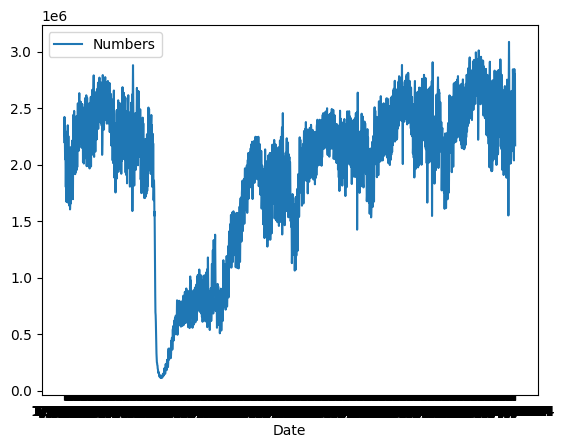

In [58]:
sns.lineplot(data=df_all)

Add a boolean column, is_thanksgiving, whose value is True on Thanksgiving day itself for the years in question and False otherwise. Add a second boolean columns, is_near_thanksgiving, whose value is True if the date is within four days of Thanksgiving. If you are doing this before data for Thanksgiving has been published, then just repeat the most recent value through Thanksgiving Day of this year (i.e., Thursday, November 27th). Recreate the line plot, but assigning the color based on the value of is_near_thanksgiving. What do you see?


In [59]:
import numpy as np

In [ ]:
#date.month == 11 ensures the date is in November.
#date.weekday() == 3 ensures it's a Thursday (0=Monday, 3=Thursday).
#22 <= date.day <= 28 ensures it’s the 4th Thursday

df_all["Is_Thanksgiving"] = np.where((df_all.index.month==11) & (df_all.index.day >= 22) & (df_all.index.day <= 28), 'Thanksgiving', 'Not Thanksgiving')



,Numbers,Is_Thanksgiving
Date,,
2019-01-01,2201765,Not Thanksgiving
2019-01-02,2424225,Not Thanksgiving
2019-01-03,2279384,Not Thanksgiving
2019-01-04,2230078,Not Thanksgiving
2019-01-05,2049460,Not Thanksgiving
...,...,...
2024-12-27,2848156,Not Thanksgiving
2024-12-28,2741872,Not Thanksgiving
2024-12-29,2805401,Not Thanksgiving
